# Problem

Design and implement a DL model capable of learning the underlying structure, grammar, and contextual dependencies of a given text corpus to generate coherent and meaningful text sequences using vanilla RNN, LSTM, and GRU.

# Resource
https://colab.research.google.com/drive/1NX4VVo4BTSoSGgt9rJ79fXkEeBAFuyqy

# Import All Dependencies

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, GRU, Dense
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam



#Data

In [2]:
raw_corpus = """
The sun was setting over the quiet village as the old man walked home.
He thought about the years he had spent working in the fields.
The wind carried the smell of fresh rain and cut grass.
Children were playing near the river while their parents watched from a distance.
Life in the village moved slowly, but everyone seemed content with their simple routine.
"""


# Data Ingestion and Data Cleaning

In [3]:
def clean_text(text):
    text = text.lower()
    text = text.replace("\n", " ")
    allowed = "abcdefghijklmnopqrstuvwxyz "
    text = "".join(ch if ch in allowed else " " for ch in text)
    text = " ".join(text.split())
    return text

corpus_text = clean_text(raw_corpus)
corpus_lines = [line.strip() for line in raw_corpus.strip().split(".") if line.strip()]
corpus_lines = [clean_text(line) for line in corpus_lines]

print(f"Number of lines: {len(corpus_lines)}")
print(corpus_lines[:3])


Number of lines: 5
['the sun was setting over the quiet village as the old man walked home', 'he thought about the years he had spent working in the fields', 'the wind carried the smell of fresh rain and cut grass']


#Tokenization

Process of breaking down a text into a smaller unit.

In [4]:
tokenizer = Tokenizer()
tokenizer.fit_on_texts(corpus_lines)
vocab_size = len(tokenizer.word_index) + 1

print(f"Vocabulary size: {vocab_size}")

Vocabulary size: 53


# N-Gram Sequence Generation and Padding

An N-Gram is a sequence of N consecutive words.

Padding means adding a special value so that all sequences have the same length

In [5]:
input_sequences = []
for line in corpus_lines:
    token_list = tokenizer.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        n_gram_sequence = token_list[: i + 1]
        input_sequences.append(n_gram_sequence)

max_sequence_len = max(len(seq) for seq in input_sequences)
input_sequences = pad_sequences(input_sequences, maxlen=max_sequence_len, padding="pre")

X = input_sequences[:, :-1]
labels = input_sequences[:, -1]
y = to_categorical(labels, num_classes=vocab_size)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"max_sequence_len: {max_sequence_len}")

X shape: (59, 13)
y shape: (59, 53)
max_sequence_len: 14


# Vanilla Simple RNN

In [6]:
def build_vanilla_rnn():
  model = Sequential([
      Embedding(vocab_size, 10, input_length=max_sequence_len - 1),
      SimpleRNN(64),
      Dense(vocab_size,activation="softmax")
  ])
  model.compile(loss="categorical_crossentropy",optimizer=Adam(learning_rate=0.01))
  return model

simpleRNN = build_vanilla_rnn()
simpleRNN.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# LSTM Model

LSTM uses input, forget, and output gates
to preserve long-term memory.

In [7]:
def build_lstm():
  model = Sequential([
      Embedding(vocab_size, 10, input_length=max_sequence_len - 1),
      LSTM(64),
      Dense(vocab_size,activation="softmax")
  ])
  model.compile(loss="categorical_crossentropy",optimizer=Adam(learning_rate=0.01))
  return model

lstm_model = build_lstm()
lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# GRU

GRU uses reset + update gates.
It is computationally faster than LSTM and often gives similar results.

In [8]:
def build_gru():
  model = Sequential([
      Embedding(vocab_size, 10, input_length=max_sequence_len - 1),
      GRU(64),
      Dense(vocab_size,activation="softmax")
  ])
  model.compile(loss="categorical_crossentropy",optimizer=Adam(learning_rate=0.01))
  return model

gru_model = build_gru()
gru_model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

# Train All Model

In [9]:
print("Training Simple RNN")
history_rnn = simpleRNN.fit(X, y, epochs=100, verbose=0)

print("Training LSTM")
history_lstm = lstm_model.fit(X, y, epochs=100, verbose=0)

print("Trainin GRU")
history_gru = gru_model.fit(X, y, epochs=100, verbose=0)


Training Simple RNN
Training LSTM
Trainin GRU


# Plot training loss curves to compare stabilization speed


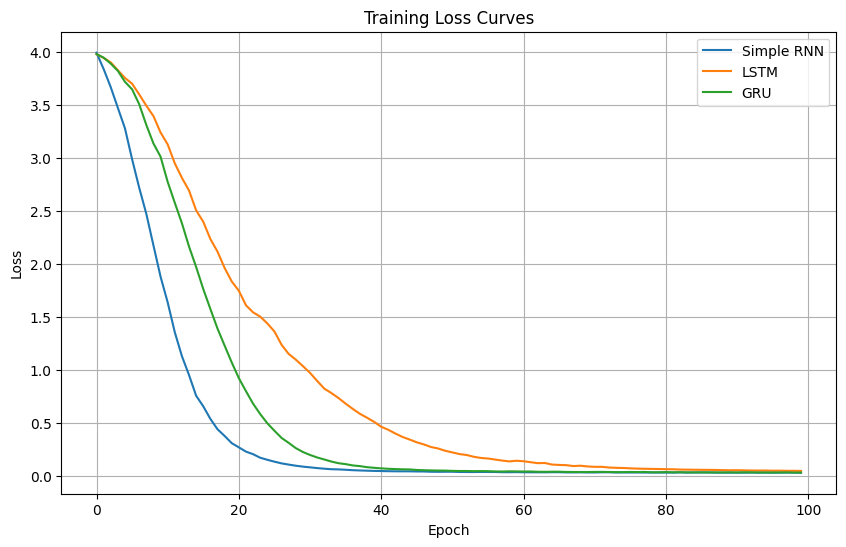

In [10]:
plt.figure(figsize=(10, 6))
plt.plot(history_rnn.history['loss'], label='Simple RNN')
plt.plot(history_lstm.history['loss'], label='LSTM')
plt.plot(history_gru.history['loss'], label='GRU')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Curves')
plt.legend()
plt.grid(True)
plt.show()

# Observation

The graph compares the training loss of Simple RNN, LSTM, and GRU over 100 epochs. All three models start with a high loss of around 4 and gradually reduce it as training progresses.

The Simple RNN converges the fastest due to its simpler architecture, while the LSTM learns more slowly because of its complex gate structure.The GRU provides a balance, converging faster than LSTM but slower than Simple RNN. By the end of training, all three models achieve a very low loss, indicating that they have successfully learned the training data.


In [12]:
def generate_text(seed_text, next_words, model, tokenizer, max_sequence_len):
    for _ in range(next_words):
        token_list = tokenizer.texts_to_sequences([seed_text])[0]
        token_list = pad_sequences([token_list], maxlen=max_sequence_len - 1, padding="pre")

        predicted_probs = model.predict(token_list, verbose=0)[0]
        predicted_index = np.argmax(predicted_probs)

        output_word = ""
        for word, index in tokenizer.word_index.items():
            if index == predicted_index:
                output_word = word
                break

        if output_word == "":
            break

        seed_text += " " + output_word

    return seed_text

seed = "the sun"
print("SimpleRNN:", generate_text(seed, 5, simpleRNN, tokenizer, max_sequence_len))
print("LSTM:     ", generate_text(seed, 5, lstm_model, tokenizer, max_sequence_len))
print("GRU:      ", generate_text(seed, 5, gru_model, tokenizer, max_sequence_len))

SimpleRNN: the sun was setting over the quiet
LSTM:      the sun was setting over the quiet
GRU:       the sun was setting over the quiet


#Observation

All three models performed well in predicting the next five words. This indicates that for a small and simple corpus, a Simple RNN is sufficient and can achieve performance comparable to LSTM and GRU, while being computationally more efficient due to its simpler architecture.

In [13]:
raw_corpus_custom = """
I am Deepak Paliwal, a third-year B.Tech Computer Science and Engineering student at DIT University.
I am passionate about software development, data structures and algorithms, and artificial intelligence.
I enjoy building real-world projects, exploring machine learning, and continuously improving my problem-solving skills through coding.
I am always eager to learn new technologies, take on challenging problems, and grow as a software engineer.
"""

corpus_lines_custom = [clean_text(line) for line in raw_corpus_custom.strip().split(".") if line.strip()]

tokenizer_custom = Tokenizer()
tokenizer_custom.fit_on_texts(corpus_lines_custom)
vocab_size_custom = len(tokenizer_custom.word_index) + 1

input_sequences_custom = []
for line in corpus_lines_custom:
    token_list = tokenizer_custom.texts_to_sequences([line])[0]
    for i in range(1, len(token_list)):
        input_sequences_custom.append(token_list[: i + 1])

max_sequence_len_custom = max(len(seq) for seq in input_sequences_custom)
input_sequences_custom = pad_sequences(input_sequences_custom, maxlen=max_sequence_len_custom, padding="pre")

X_custom = input_sequences_custom[:, :-1]
labels_custom = input_sequences_custom[:, -1]
y_custom = to_categorical(labels_custom, num_classes=vocab_size_custom)

print(f"Custom vocab size: {vocab_size_custom}")
print(f"X_custom shape: {X_custom.shape}")

Custom vocab size: 56
X_custom shape: (61, 17)


In [14]:
def build_gru_model_custom():
    model = Sequential([
        Embedding(vocab_size_custom, 100, input_length=max_sequence_len_custom - 1),
        GRU(128),
        Dense(vocab_size_custom, activation="softmax"),
    ])
    model.compile(loss="categorical_crossentropy", optimizer=Adam(learning_rate=0.01), metrics=["accuracy"])
    return model

gru_model_custom = build_gru_model_custom()
gru_model_custom.summary()

history_gru_custom = gru_model_custom.fit(X_custom, y_custom, epochs=200, verbose=0)
print("Custom GRU training complete.")


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Custom GRU training complete.


In [15]:
seed_custom = "deep learning"
generated = generate_text(seed_custom, 10, gru_model_custom, tokenizer_custom, max_sequence_len_custom)
print("Generated (10 words):", generated)

Generated (10 words): deep learning and engineering student at dit university university university university and


#Observation

The GRU model successfully learned the patterns present in the custom corpus and generated contextually relevant text. However, the output contains repeated words such as "university", indicating overfitting and limited vocabulary due to the small training dataset and greedy decoding strategy. To overcome this issue we can use a larger corpus, fewer training epochs, or probabilistic sampling can produce more diverse and natural text.